# Health Insurance Member Utilization Risk — End-to-End

Run the cells from top to bottom to inspect the supplied CSV data, generate EDA reports, build the member-level feature table and proxy target, create the train/validation/test/production partitions, compare and tune multiclass models, evaluate on the held-out test set, and save production predictions.

**Target limitation:** The source files do not contain an observed utilization-risk label or claims costs. `Member_Utilization_Risk` is a documented proxy based on annualized visit counts in the final third of each eligible member's observation period. Its Low/Medium/High thresholds are learned from training members only. This is not a validated insurance-cost, clinical, or actuarial risk score. Review the project README before interpreting results.

The notebook uses pandas and scikit-learn with local CSV files; it does not require a database.

## 1. Locate the project and load libraries

Run this notebook from the project root or its `notebooks/` folder. The Python environment must have the packages listed in `requirements.txt` installed.

In [2]:
from pathlib import Path
import sys
import json

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

candidates = [Path.cwd(), *Path.cwd().parents]
PROJECT_ROOT = next(
    (path.resolve() for path in candidates if (path / "dataset").is_dir() and (path / "src").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate project root containing both dataset/ and src/.")

sys.path.insert(0, str(PROJECT_ROOT / "src"))
from utilization_risk.config import CLASSES, DATASET_DIR, OUTPUTS_DIR, REPORTS_DIR, TARGET
from utilization_risk.eda import write_eda_report
from utilization_risk.pipeline import run_pipeline

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset folder: {DATASET_DIR}")
print(f"Python executable: {sys.executable}")

Project root: C:\Users\riyaz\OneDrive\Desktop\USD\Module9_MLOps\Week7 Project\Project 6 Oct
Dataset folder: C:\Users\riyaz\OneDrive\Desktop\USD\Module9_MLOps\Week7 Project\Project 6 Oct\dataset
Python executable: c:\Users\riyaz\anaconda3\envs\USDProject\python.exe


## 2. Check the raw CSV dataset

This quick inventory checks file availability, approximate file size, and headers without loading the large event tables into memory.

In [2]:
csv_paths = sorted(DATASET_DIR.rglob("*.csv"))
if not csv_paths:
    raise FileNotFoundError(f"No CSV files found under {DATASET_DIR}")

source_files = []
for path in csv_paths:
    headers = pd.read_csv(path, nrows=0).columns.tolist()
    source_files.append(
        {
            "table": path.parent.name,
            "file": str(path.relative_to(DATASET_DIR)),
            "size_mb": round(path.stat().st_size / (1024**2), 1),
            "columns": len(headers),
            "has_person_id": "person_id" in headers,
        }
    )
source_overview = pd.DataFrame(source_files)
display(source_overview)
print(f"Found {len(source_overview)} CSV files; total size {source_overview['size_mb'].sum():,.1f} MB.")

,table,file,size_mb,columns,has_person_id
0,care_site,care_site\care_site.csv,7.9,6,False
1,condition_era,condition_era\condition_era.csv,448.3,6,True
2,condition_occurrence,condition_occurrence\condition_occurrence.csv,1388.3,15,True
3,death,death\death.csv,0.1,7,True
4,device_exposure,device_exposure\device_exposure.csv,20.6,14,True
5,drug_era,drug_era\drug_era.csv,252.8,7,True
6,drug_exposure,drug_exposure\drug_exposure.csv,678.0,22,True
7,drug_strength,drug_strength\drug_strength.csv,133.7,12,False
8,location,location\location.csv,0.1,8,False
9,measurement,measurement\measurement.csv,231.8,18,True


Found 17 CSV files; total size 4,894.7 MB.


## 3. Exploratory data analysis

Scan each CSV in chunks to produce row counts, member coverage, table-level missingness, and per-column missingness. The reports are written under `reports/`. Missing optional values are imputed later inside training-fitted model pipelines; members are not dropped wholesale because of sparse demographics.

In [3]:
inventory, eda_report_path = write_eda_report(DATASET_DIR, REPORTS_DIR)
column_missingness = pd.read_csv(REPORTS_DIR / "column_missingness.csv")
display(inventory)
print(f"EDA report saved to: {eda_report_path}")
print(f"Column missingness saved to: {REPORTS_DIR / 'column_missingness.csv'}")

EDA report: C:\Users\riyaz\OneDrive\Desktop\USD\Module9_MLOps\Week7 Project\Project 6 Oct\reports\eda_report.md
Dataset inventory: C:\Users\riyaz\OneDrive\Desktop\USD\Module9_MLOps\Week7 Project\Project 6 Oct\reports\dataset_inventory.csv


,table,file,rows,columns,mean_missing_fraction,unique_person_ids
0,care_site,care_site\care_site.csv,320545,6,0.333333,
1,condition_era,condition_era\condition_era.csv,9788262,6,0.000000,84608
2,condition_occurrence,condition_occurrence\condition_occurrence.csv,12695221,15,0.133516,84608
3,death,death\death.csv,4635,7,0.428571,4635
4,device_exposure,device_exposure\device_exposure.csv,202805,14,0.214537,36431
5,drug_era,drug_era\drug_era.csv,5365324,7,0.142857,88243
6,drug_exposure,drug_exposure\drug_exposure.csv,5423469,22,0.460063,88706
7,drug_strength,drug_strength\drug_strength.csv,2430381,12,0.410008,
8,location,location\location.csv,3185,8,0.500000,
9,measurement,measurement\measurement.csv,2909229,18,0.444734,79106


EDA report saved to: C:\Users\riyaz\OneDrive\Desktop\USD\Module9_MLOps\Week7 Project\Project 6 Oct\reports\eda_report.md
Column missingness saved to: C:\Users\riyaz\OneDrive\Desktop\USD\Module9_MLOps\Week7 Project\Project 6 Oct\reports\column_missingness.csv


In [4]:
display(
    column_missingness.sort_values("missing_fraction", ascending=False)
    .head(25)
    .style.format({"missing_fraction": "{:.1%}"})
)

,table,column,missing_values,missing_fraction
1,care_site,care_site_name,320545,100.0%
3,care_site,location_id,320545,100.0%
68,drug_exposure,sig,5423469,100.0%
64,drug_exposure,stop_reason,5423469,100.0%
62,drug_exposure,verbatim_end_date,5423469,100.0%
29,death,death_datetime,4635,100.0%
31,death,cause_concept_id,4635,100.0%
32,death,cause_source_value,4635,100.0%
40,device_exposure,device_exposure_end_datetime,202805,100.0%
42,device_exposure,unique_device_id,202805,100.0%


## 4. Merge tables, engineer features, and create the target

The pipeline keeps one row per member. Event files are aggregated by `person_id` before they are merged, avoiding event-to-event many-to-many joins. Features use only records dated before each member's prediction date. The target is based on future visits after that date, so those visits are never model inputs. Numeric values are median-imputed and standardized; categorical concept codes are imputed and one-hot encoded. These transformations are fitted only on training data.

In [3]:
run_result = run_pipeline(dataset_dir=DATASET_DIR, outputs_dir=OUTPUTS_DIR)
partitions = run_result["partitions"]
model_comparison = run_result["comparison"]
test_metrics = run_result["metrics"]

display(model_comparison)
print("Selected model:", model_comparison.iloc[0]["model"])
print("Held-out test metrics:", test_metrics)

Model comparison (validation):
              model  accuracy  f1_macro  f1_weighted
            xgboost  0.731180  0.734690     0.734767
      random_forest  0.729801  0.733154     0.733241
        extra_trees  0.727618  0.731243     0.731326
logistic_regression  0.697621  0.697821     0.697867
      decision_tree  0.627169  0.625912     0.625970

Selected model: xgboost
Test metrics: {'accuracy': 0.7350879209286288, 'f1_macro': 0.738537776501949, 'f1_weighted': 0.738165513572451}
Artifacts saved under: C:\Users\riyaz\OneDrive\Desktop\USD\Module9_MLOps\Week7 Project\Project 6 Oct\outputs


,model,accuracy,f1_macro,f1_weighted
4,xgboost,0.731180,0.734690,0.734767
2,random_forest,0.729801,0.733154,0.733241
3,extra_trees,0.727618,0.731243,0.731326
0,logistic_regression,0.697621,0.697821,0.697867
1,decision_tree,0.627169,0.625912,0.625970


Selected model: xgboost
Held-out test metrics: {'accuracy': 0.7350879209286288, 'f1_macro': 0.738537776501949, 'f1_weighted': 0.738165513572451}


## 5. Review final model features and target distribution

`person_id` is a join/split key, not a predictive feature. The target is also excluded from the feature set. Production members have features only and no target label.

In [6]:
model_features = [
    column for column in partitions.train.columns
    if column not in {"person_id", TARGET}
]
print(f"Final model feature count: {len(model_features)}")
display(pd.DataFrame({"model_feature": model_features}))

distribution_rows = []
for split_name, split_data in [
    ("train", partitions.train),
    ("validation", partitions.validation),
    ("test", partitions.test),
]:
    counts = split_data[TARGET].value_counts().reindex(CLASSES, fill_value=0)
    for class_name, count in counts.items():
        distribution_rows.append(
            {
                "split": split_name,
                "class": class_name,
                "members": int(count),
                "percent": count / len(split_data) * 100,
            }
        )
class_distribution = pd.DataFrame(distribution_rows)
display(class_distribution.pivot(index="class", columns="split", values="members").reindex(CLASSES))
display(class_distribution.pivot(index="class", columns="split", values="percent").reindex(CLASSES).style.format("{:.2f}%"))

partition_sizes = {
    "train": len(partitions.train),
    "validation": len(partitions.validation),
    "test": len(partitions.test),
    "production": len(partitions.production),
}
print("Partition sizes:", partition_sizes)
print("Production partition includes target?", TARGET in partitions.production.columns)

Final model feature count: 13


,model_feature
0,gender_concept_id
1,race_concept_id
2,ethnicity_concept_id
3,age_at_index
4,baseline_years
5,visits_baseline_count
6,conditions_baseline_count
7,procedures_baseline_count
8,drug_exposures_baseline_count
9,measurements_baseline_count


split,test,train,validation
class,,,
Low,2832,11607,2889
Medium,2907,11608,2890
High,2962,11592,2922


split,test,train,validation
class,,,
Low,32.55%,33.35%,33.20%
Medium,33.41%,33.35%,33.21%
High,34.04%,33.30%,33.58%


Partition sizes: {'train': 34807, 'validation': 8701, 'test': 8701, 'production': 34810}
Production partition includes target? False


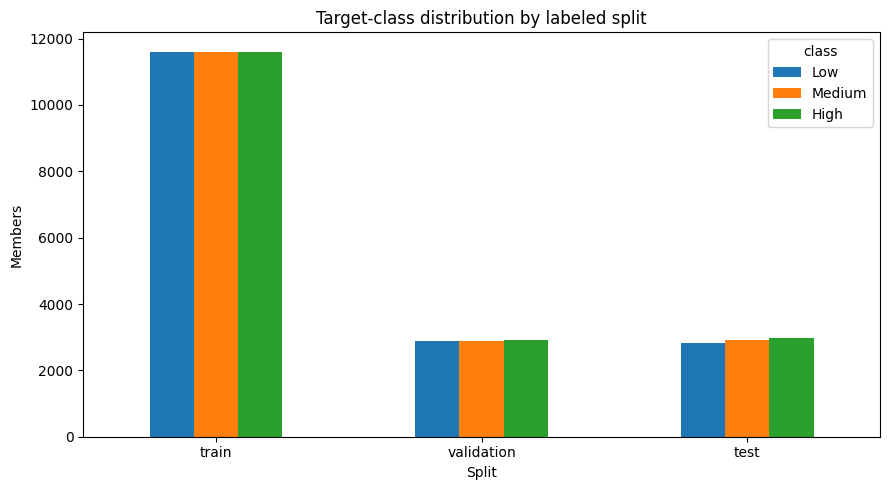

In [7]:
class_distribution.pivot(index="split", columns="class", values="members").reindex(
    index=["train", "validation", "test"], columns=CLASSES
).plot(kind="bar", figsize=(9, 5), title="Target-class distribution by labeled split")
plt.xlabel("Split")
plt.ylabel("Members")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Model comparison, tuning, and held-out evaluation

Logistic Regression, Decision Tree, Random Forest, Extra Trees, and XGBoost are compared on validation accuracy and macro-F1. The best validation candidate is tuned with cross-validation on training members only, then evaluated on the test partition. Per-class scores and the confusion matrix help assess performance beyond overall accuracy.

In [4]:
display(model_comparison.style.format({"accuracy": "{:.3f}", "f1_macro": "{:.3f}", "f1_weighted": "{:.3f}"}))
test_report = pd.read_csv(OUTPUTS_DIR / "evaluation" / "test_classification_report.csv", index_col=0)
test_confusion_matrix = pd.read_csv(OUTPUTS_DIR / "evaluation" / "test_confusion_matrix.csv", index_col=0)
display(test_report)
display(test_confusion_matrix)
print("Test accuracy: {:.3f}".format(test_metrics["accuracy"]))
print("Test macro-F1: {:.3f}".format(test_metrics["f1_macro"]))
print("Test weighted-F1: {:.3f}".format(test_metrics["f1_weighted"]))

,model,accuracy,f1_macro,f1_weighted
4,xgboost,0.731,0.735,0.735
2,random_forest,0.730,0.733,0.733
3,extra_trees,0.728,0.731,0.731
0,logistic_regression,0.698,0.698,0.698
1,decision_tree,0.627,0.626,0.626


,precision,recall,f1-score,support
Low,0.902741,0.721045,0.801728,2832.000000
Medium,0.619511,0.679395,0.648072,2907.000000
High,0.731775,0.803174,0.765814,2962.000000
accuracy,0.735088,0.735088,0.735088,0.735088
macro avg,0.751342,0.734538,0.738538,8701.000000
weighted avg,0.749913,0.735088,0.738166,8701.000000


,Low,Medium,High
actual,,,
Low,2042,638,152
Medium,212,1975,720
High,8,575,2379


Test accuracy: 0.735
Test macro-F1: 0.739
Test weighted-F1: 0.738


## 7. Production predictions and saved artifacts

The reserved production partition is not used to train, tune, or evaluate the model. Its predictions are saved separately from the labeled training/evaluation data.

In [5]:
production_predictions = pd.read_csv(OUTPUTS_DIR / "predictions" / "production_predictions.csv")
production_distribution = (
    production_predictions[TARGET]
    .value_counts()
    .reindex(CLASSES, fill_value=0)
    .rename_axis(TARGET)
    .reset_index(name="members")
)
display(production_distribution)
display(production_predictions.head())

artifact_paths = [
    REPORTS_DIR / "eda_report.md",
    REPORTS_DIR / "dataset_inventory.csv",
    REPORTS_DIR / "column_missingness.csv",
    OUTPUTS_DIR / "processed" / "member_features_labeled.csv",
    OUTPUTS_DIR / "splits" / "train.csv",
    OUTPUTS_DIR / "splits" / "validation.csv",
    OUTPUTS_DIR / "splits" / "test.csv",
    OUTPUTS_DIR / "splits" / "production_features.csv",
    OUTPUTS_DIR / "model" / "best_model.joblib",
    OUTPUTS_DIR / "model" / "model_metadata.json",
    OUTPUTS_DIR / "evaluation" / "model_comparison.csv",
    OUTPUTS_DIR / "evaluation" / "test_metrics.json",
    OUTPUTS_DIR / "evaluation" / "test_classification_report.csv",
    OUTPUTS_DIR / "evaluation" / "test_confusion_matrix.csv",
    OUTPUTS_DIR / "predictions" / "production_predictions.csv",
]
display(pd.DataFrame({"artifact": [str(path.relative_to(PROJECT_ROOT)) for path in artifact_paths], "exists": [path.is_file() for path in artifact_paths]}))

,Member_Utilization_Risk,members
0,Low,9270
1,Medium,12701
2,High,12839


,person_id,Member_Utilization_Risk
0,1734951,Medium
1,1710712,High
2,932806,Low
3,1894571,High
4,1237748,Low


,artifact,exists
0,reports\eda_report.md,True
1,reports\dataset_inventory.csv,True
2,reports\column_missingness.csv,True
3,outputs\processed\member_features_labeled.csv,True
4,outputs\splits\train.csv,True
5,outputs\splits\validation.csv,True
6,outputs\splits\test.csv,True
7,outputs\splits\production_features.csv,True
8,outputs\model\best_model.joblib,True
9,outputs\model\model_metadata.json,True


## Interpretation and limitations

The target measures relative future visit intensity, not insurance spend, paid claims, medical necessity, or a validated risk score. Its tercile thresholds are specific to the training cohort. Before any real use, define a business/clinical outcome and time horizon, validate against actual plan claims and prospective data, and conduct appropriate fairness and governance reviews. Do not use this proxy to make individual coverage or care decisions.